# Phase 5: Exploratory Data Analysis & Demand Profiling
Statistical characterization of multi-branch retail pharmacy sales: Syntetos-Boylan classification, temporal seasonality, and ABC Pareto segmentation.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Resolve project root dynamically across all execution contexts
PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT.name and not ((PROJECT_ROOT / "data").exists() and (PROJECT_ROOT / "src").exists()):
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

from src.features.demand_profiler import DemandProfiler, CrostonThresholds

profiler = DemandProfiler(data_dir=RAW_DIR)
profiler.load_data()
profiles_df = profiler.generate_full_profiles()
seasonality = profiler.compute_temporal_seasonality()

print(f"[+] Total Series Profiled: {len(profiles_df)}")
print(profiles_df['demand_pattern'].value_counts())

[+] Total Series Profiled: 516
demand_pattern
Smooth          499
Intermittent     17
Name: count, dtype: int64


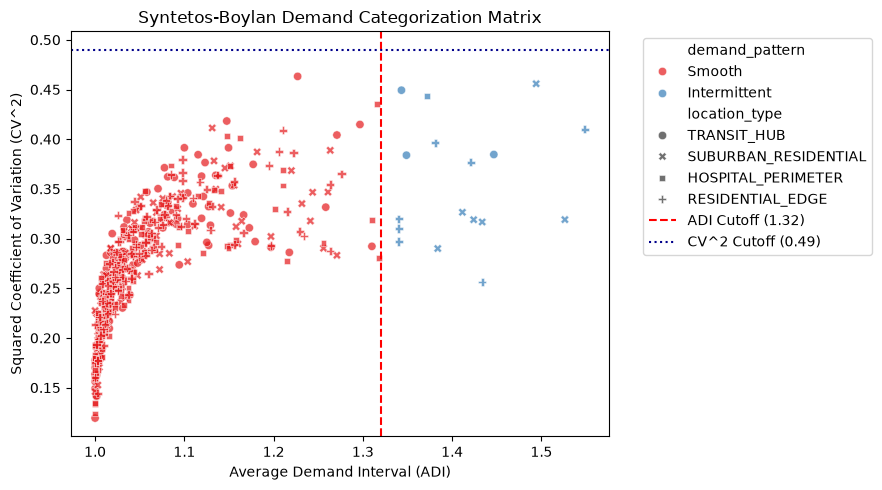

In [2]:
# Syntetos-Boylan (Croston) Matrix: ADI vs CV^2
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=profiles_df,
    x="adi",
    y="cv2",
    hue="demand_pattern",
    style="location_type",
    alpha=0.7,
    palette="Set1"
)
plt.axvline(CrostonThresholds.ADI_CUTOFF, color="red", linestyle="--", label=f"ADI Cutoff ({CrostonThresholds.ADI_CUTOFF})")
plt.axhline(CrostonThresholds.CV2_CUTOFF, color="darkblue", linestyle=":", label=f"CV^2 Cutoff ({CrostonThresholds.CV2_CUTOFF})")
plt.title("Syntetos-Boylan Demand Categorization Matrix")
plt.xlabel("Average Demand Interval (ADI)")
plt.ylabel("Squared Coefficient of Variation (CV^2)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

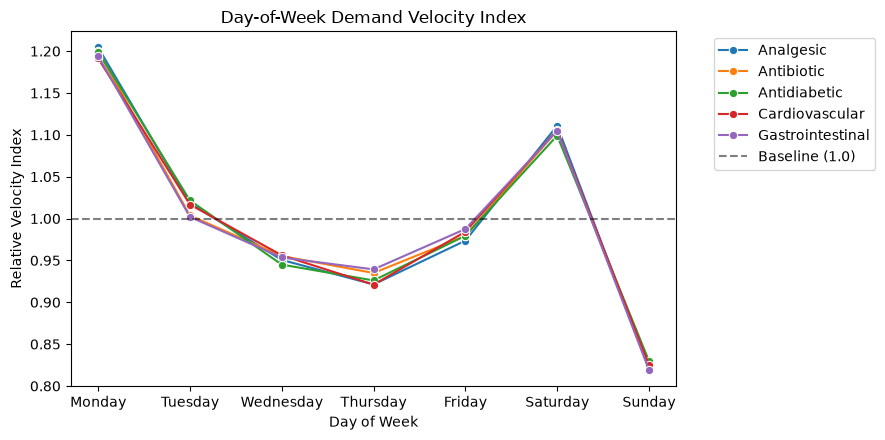

In [3]:
# Day-of-Week Seasonality Index
dow_df = seasonality["day_of_week_index"]
key_categories = ["Cardiovascular", "Antidiabetic", "Antibiotic", "Analgesic", "Gastrointestinal"]
subset_dow = dow_df[dow_df["category"].isin(key_categories)]

plt.figure(figsize=(9, 4.5))
sns.lineplot(
    data=subset_dow,
    x="day_of_week",
    y="dow_index",
    hue="category",
    marker="o"
)
plt.axhline(1.0, color="black", linestyle="--", alpha=0.5, label="Baseline (1.0)")
plt.title("Day-of-Week Demand Velocity Index")
plt.xlabel("Day of Week")
plt.ylabel("Relative Velocity Index")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

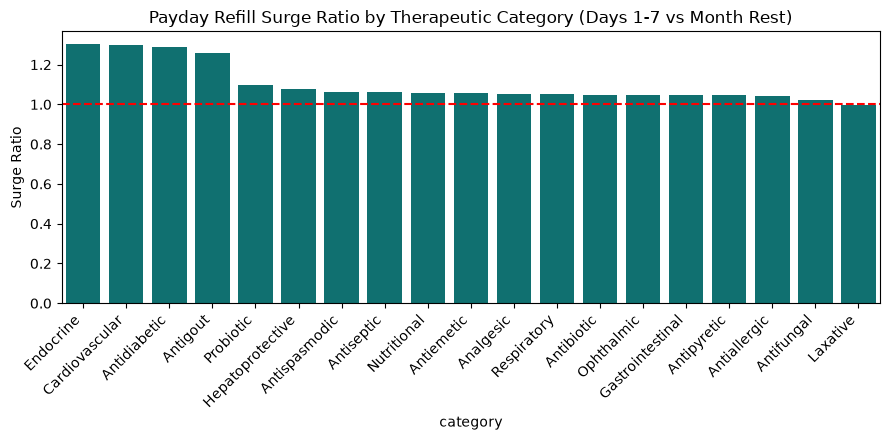

In [4]:
# Payday Refill Surge (Days 1-7)
payday_df = seasonality["payday_surge"].sort_values(by="payday_surge_ratio", ascending=False)

plt.figure(figsize=(9, 4.5))
sns.barplot(data=payday_df, x="category", y="payday_surge_ratio", color="teal")
plt.axhline(1.0, color="red", linestyle="--", label="Neutral Baseline (1.0)")
plt.xticks(rotation=45, ha="right")
plt.title("Payday Refill Surge Ratio by Therapeutic Category (Days 1-7 vs Month Rest)")
plt.ylabel("Surge Ratio")
plt.tight_layout()
plt.show()

In [5]:
# ABC Pareto Revenue Distribution
abc_summary = profiles_df.groupby("abc_class").agg(
    sku_count=("medicine_id", "nunique"),
    total_revenue=("total_revenue", "sum")
).reset_index()
abc_summary["revenue_share"] = (abc_summary["total_revenue"] / abc_summary["total_revenue"].sum()).round(4)
display(abc_summary)

# Export confirmation
export_target = profiler.export_profiles(PROCESSED_DIR / "sku_demand_profiles.csv")
print(f"[+] Profile exported to: {export_target}")

,abc_class,sku_count,total_revenue,revenue_share
0,A,70,1.149089e+08,0.7950
1,B,35,2.234856e+07,0.1546
2,C,24,7.282761e+06,0.0504


[+] Profile exported to: D:\RemediSync\data\processed\sku_demand_profiles.csv
